In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.transforms as transforms
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
import numpy as np
import os
import math

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")


Using device: cuda
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [2]:
DATA_DIR = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

# Transforms: resize is critical — we need 224 to get 196 patches
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),        # 64×64 → 224×224
    transforms.RandomHorizontalFlip(),     # Data augmentation (free!)
    transforms.ToTensor(),                 # [0,255] → [0.0, 1.0]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        # ImageNet statistics
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load datasets
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, 'train'),
    transform=transform_train
)
val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, 'val'),
    transform=transform_val
)

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,     # Speeds up CPU→GPU transfer
    drop_last=True       # Drop incomplete last batch (keeps batch size consistent)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Training samples: 100000
Validation samples: 10000
Batches per epoch: 1562


In [3]:
class PatchEmbedding(nn.Module):
    """Converts image into a sequence of patch embeddings."""
    
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 196
        self.patch_dim = in_channels * patch_size * patch_size   # 768
        
        # Conv2d with kernel=stride=16 acts as patch extraction + linear projection
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
    
    def forward(self, x):
        # x: (B, 3, 224, 224)
        B = x.shape[0]
        x = self.projection(x)         # (B, embed_dim, 14, 14)
        x = x.flatten(2)               # (B, embed_dim, 196) — flatten spatial dims
        x = x.transpose(1, 2)          # (B, 196, embed_dim) — sequence format
        return x


In [4]:
def get_sinusoidal_positional_embedding(num_positions, embed_dim):
    """
    Generate sinusoidal positional embeddings.
    
    Args:
        num_positions: number of positions (196 patches)
        embed_dim: embedding dimension (768 for encoder, 384 for decoder)
    
    Returns:
        Tensor of shape (1, num_positions, embed_dim)
    """
    position = torch.arange(num_positions).unsqueeze(1).float()  # (196, 1)
    
    # Create dimension indices: 0, 2, 4, ..., embed_dim-2
    div_term = torch.exp(
        torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
    )
    # div_term = 1 / 10000^(2i/d), computed in log space for numerical stability
    
    pe = torch.zeros(num_positions, embed_dim)
    pe[:, 0::2] = torch.sin(position * div_term)  # Even indices: sin
    pe[:, 1::2] = torch.cos(position * div_term)  # Odd indices: cos
    
    return pe.unsqueeze(0)  # (1, num_positions, embed_dim) — 1 for batch broadcasting


In [6]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self-Attention mechanism."""
    
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads  # 768/12 = 64 per head
        self.scale = self.head_dim ** -0.5       # 1/√64 = 0.125
        
        # Single linear layer for Q, K, V (more efficient than 3 separate ones)
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)  # Output projection
    
    def forward(self, x):
        B, N, C = x.shape  # Batch, num_tokens, embed_dim
        
        # Compute Q, K, V in one shot
        qkv = self.qkv(x)  # (B, N, 3*C)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)  # Each: (B, heads, N, head_dim)
        
        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        
        # Weighted sum of values
        x = (attn @ v)  # (B, heads, N, head_dim)
        x = x.transpose(1, 2).reshape(B, N, C)  # Concatenate heads
        x = self.proj(x)  # Output projection
        return x


class FeedForward(nn.Module):
    """Feed-Forward Network with GELU activation."""
    
    def __init__(self, embed_dim, mlp_ratio=4.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)    # 768 → 3072
        self.act = nn.GELU()                             # Smooth ReLU variant
        self.fc2 = nn.Linear(hidden_dim, embed_dim)     # 3072 → 768
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x


class TransformerBlock(nn.Module):
    """Single Transformer block with pre-norm."""
    
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = FeedForward(embed_dim, mlp_ratio)
    
    def forward(self, x):
        # Pre-norm: normalize BEFORE the sub-layer
        x = x + self.attn(self.norm1(x))   # Residual + Attention
        x = x + self.ffn(self.norm2(x))    # Residual + FFN
        return x


In [7]:
class MAEEncoder(nn.Module):
    """
    ViT-Base encoder for MAE.
    Processes ONLY visible (unmasked) patches.
    """
    
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=768,
        depth=12,
        num_heads=12
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.num_patches = self.patch_embed.num_patches  # 196
        
        # Positional embeddings (fixed, not learned)
        # Register as buffer so it's moved to GPU with model but not trained
        self.register_buffer(
            'pos_embed',
            get_sinusoidal_positional_embedding(self.num_patches, embed_dim)
        )
        
        # Stack of transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)  # Final layer norm
    
    def forward(self, x, mask):
        """
        Args:
            x: images (B, 3, 224, 224)
            mask: boolean tensor (B, num_patches) — True = KEEP, False = MASK
        
        Returns:
            visible_tokens: (B, num_visible, embed_dim)
            mask: same mask passed through
            ids_restore: indices to unshuffle tokens back to original order
        """
        # Step 1: Patchify
        x = self.patch_embed(x)  # (B, 196, 768)
        
        # Step 2: Add positional embeddings to ALL patches (before masking)
        x = x + self.pos_embed  # (B, 196, 768)
        
        # Step 3: Apply mask — keep only visible patches
        B, N, D = x.shape
        
        # Get indices of visible and masked patches
        ids_keep = mask.nonzero(as_tuple=False)  # Will be used differently
        
        # Simpler approach: use mask to select visible patches per sample
        # We need a way to restore order later
        len_keep = mask.sum(dim=1)[0].item()  # Number of visible patches (same for all)
        
        # Argsort noise to get shuffled indices, where visible patches come first
        # Use mask values as "noise" — True (1) will sort before False (0) with descending
        noise = mask.float()
        ids_shuffle = torch.argsort(noise, dim=1, descending=True)  # Visible first
        ids_restore = torch.argsort(ids_shuffle, dim=1)  # Undo the shuffle
        
        # Keep only the visible patches
        ids_keep = ids_shuffle[:, :len_keep]
        
        # Gather visible patches
        x = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
        # x is now (B, num_visible, 768)
        
        # Step 4: Pass through transformer blocks
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        
        return x, mask, ids_restore


In [8]:
class MAEDecoder(nn.Module):
    """
    ViT-Small decoder for MAE.
    Reconstructs full image from visible tokens + mask tokens.
    """
    
    def __init__(
        self,
        num_patches=196,
        patch_size=16,
        in_channels=3,
        encoder_embed_dim=768,
        decoder_embed_dim=384,
        depth=12,
        num_heads=6
    ):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        
        # Project encoder dimension → decoder dimension
        self.decoder_embed = nn.Linear(encoder_embed_dim, decoder_embed_dim)
        
        # Learnable mask token — one vector, repeated for all masked positions
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        nn.init.normal_(self.mask_token, std=0.02)  # Small random init
        
        # Positional embeddings for decoder (full 196 positions)
        self.register_buffer(
            'decoder_pos_embed',
            get_sinusoidal_positional_embedding(num_patches, decoder_embed_dim)
        )
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, num_heads)
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(decoder_embed_dim)
        
        # Final projection: decoder_dim → pixels per patch
        # 16*16*3 = 768 pixel values per patch
        self.pred = nn.Linear(decoder_embed_dim, patch_size * patch_size * in_channels)
    
    def forward(self, x, ids_restore):
        """
        Args:
            x: encoder output (B, num_visible, encoder_embed_dim)
            ids_restore: indices to unshuffle (B, num_patches)
        
        Returns:
            pred: reconstructed patches (B, num_patches, patch_size²×3)
        """
        # Step 1: Project encoder dim → decoder dim
        x = self.decoder_embed(x)  # (B, num_visible, 384)
        
        B, num_visible, D = x.shape
        num_masked = self.num_patches - num_visible  # 147
        
        # Step 2: Create mask tokens and append to visible tokens
        mask_tokens = self.mask_token.repeat(B, num_masked, 1)  # (B, 147, 384)
        
        # Concatenate visible + mask tokens
        x_full = torch.cat([x, mask_tokens], dim=1)  # (B, 196, 384)
        
        # Step 3: Unshuffle to restore original patch ordering
        # This puts each token back to its correct spatial position
        x_full = torch.gather(
            x_full, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, D)
        )  # (B, 196, 384)
        
        # Step 4: Add positional embeddings
        x_full = x_full + self.decoder_pos_embed
        
        # Step 5: Apply transformer blocks
        for block in self.blocks:
            x_full = block(x_full)
        
        x_full = self.norm(x_full)
        
        # Step 6: Predict pixel values for each patch
        pred = self.pred(x_full)  # (B, 196, 768) — 768 = 16*16*3
        
        return pred


In [9]:
class MaskedAutoencoder(nn.Module):
    """Full MAE: Encoder + Decoder + Masking."""
    
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        encoder_embed_dim=768,
        encoder_depth=12,
        encoder_num_heads=12,
        decoder_embed_dim=384,
        decoder_depth=12,
        decoder_num_heads=6,
        mask_ratio=0.75
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.num_patches = (img_size // patch_size) ** 2  # 196
        self.in_channels = in_channels
        
        # Encoder
        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=encoder_embed_dim,
            depth=encoder_depth,
            num_heads=encoder_num_heads
        )
        
        # Decoder
        self.decoder = MAEDecoder(
            num_patches=self.num_patches,
            patch_size=patch_size,
            in_channels=in_channels,
            encoder_embed_dim=encoder_embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            depth=decoder_depth,
            num_heads=decoder_num_heads
        )
    
    def patchify(self, imgs):
        """
        Convert images to patches (for loss computation target).
        imgs: (B, 3, 224, 224)
        Returns: (B, 196, 768)  — 768 = 16*16*3
        """
        p = self.patch_size
        B, C, H, W = imgs.shape
        h = w = H // p  # 14
        
        # Reshape: (B, 3, 14, 16, 14, 16) → rearrange to (B, 196, 768)
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1)  # (B, 14, 14, 16, 16, 3)
        x = x.reshape(B, h * w, p * p * C)  # (B, 196, 768)
        return x
    
    def unpatchify(self, x):
        """
        Convert patches back to images (for visualization).
        x: (B, 196, 768)
        Returns: (B, 3, 224, 224)
        """
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)  # 14
        C = self.in_channels
        
        x = x.reshape(-1, h, w, p, p, C)
        x = x.permute(0, 5, 1, 3, 2, 4)  # (B, 3, 14, 16, 14, 16)
        x = x.reshape(-1, C, h * p, w * p)  # (B, 3, 224, 224)
        return x
    
    def generate_mask(self, batch_size, device):
        """
        Generate random mask.
        Returns: boolean mask (B, 196) — True = KEEP, False = MASK
        """
        num_keep = int(self.num_patches * (1 - self.mask_ratio))  # 49
        
        # Random noise for each patch
        noise = torch.rand(batch_size, self.num_patches, device=device)
        
        # Sort noise — top num_keep indices are "visible"
        ids_shuffle = torch.argsort(noise, dim=1)
        
        # Create binary mask
        mask = torch.zeros(batch_size, self.num_patches, device=device, dtype=torch.bool)
        mask.scatter_(1, ids_shuffle[:, :num_keep], True)
        
        return mask
    
    def forward(self, imgs, mask=None):
        """
        Full forward pass.
        
        Returns:
            loss: MSE on masked patches only
            pred: reconstructed patches (B, 196, 768)
            mask: the mask used (B, 196)
        """
        if mask is None:
            mask = self.generate_mask(imgs.shape[0], imgs.device)
        
        # Encode visible patches
        latent, mask, ids_restore = self.encoder(imgs, mask)
        
        # Decode all patches
        pred = self.decoder(latent, ids_restore)
        
        # Compute loss
        target = self.patchify(imgs)  # (B, 196, 768) — original pixel values
        
        # MSE loss ONLY on masked patches
        # ~mask inverts: True (visible) → False, False (masked) → True
        loss = (pred - target) ** 2  # (B, 196, 768)
        loss = loss.mean(dim=-1)     # (B, 196) — mean over pixel values per patch
        loss = (loss * (~mask).float()).sum() / (~mask).float().sum()  # Average over masked patches only
        
        return loss, pred, mask


In [20]:
def train_mae(model, train_loader, val_loader, num_epochs=50, lr=1.5e-4, weight_decay=0.05):
    """Train the MAE model."""
    
    # Use DataParallel if multiple GPUs
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
        model = nn.DataParallel(model)
    model = model.to(device)
    
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    scaler = GradScaler()
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # ========== Training ==========
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            # _ = labels (we don't use them! Self-supervised!)
            images = images.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Mixed precision forward pass
            with autocast():
                loss, pred, mask = model(images)
                # If DataParallel, loss is per-GPU — average them
                loss = loss.mean()
            
            # Scaled backward pass
            scaler.scale(loss).backward()
            
            # Gradient clipping (unscale first, then clip)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Optimizer step with scaler
            scaler.step(optimizer)
            scaler.update()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            if batch_idx % 100 == 0:
                print(f"  Epoch [{epoch+1}/{num_epochs}] "
                      f"Batch [{batch_idx}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")
        
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # ========== Validation ==========
        model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device, non_blocking=True)
                with autocast():
                    loss, _, _ = model(images)
                    loss = loss.mean()
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches
        val_losses.append(avg_val_loss)
        
        # Step the scheduler
        scheduler.step()

        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            model_to_save = model.module if hasattr(model, 'module') else model
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model_to_save.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses,
            }
            torch.save(checkpoint, f'mae_checkpoint_epoch_{epoch+1}.pth')
            print(f"  ✅ Checkpoint saved at epoch {epoch+1}")

        print(f"Epoch [{epoch+1}/{num_epochs}] ...")
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")
    
    return train_losses, val_losses


Total parameters: 107.5M
Encoder parameters: 85.6M
Decoder parameters: 21.9M
Using 2 GPUs with DataParallel


/tmp/ipykernel_55/617720365.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/617720365.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch [1/35] Batch [0/1562] Loss: 1.7272
  Epoch [1/35] Batch [100/1562] Loss: 0.8810
  Epoch [1/35] Batch [200/1562] Loss: 0.7654
  Epoch [1/35] Batch [300/1562] Loss: 0.5746
  Epoch [1/35] Batch [400/1562] Loss: 0.5014
  Epoch [1/35] Batch [500/1562] Loss: 0.4421
  Epoch [1/35] Batch [600/1562] Loss: 0.4801
  Epoch [1/35] Batch [700/1562] Loss: 0.4733
  Epoch [1/35] Batch [800/1562] Loss: 0.3638
  Epoch [1/35] Batch [900/1562] Loss: 0.4014
  Epoch [1/35] Batch [1000/1562] Loss: 0.3951
  Epoch [1/35] Batch [1100/1562] Loss: 0.4590
  Epoch [1/35] Batch [1200/1562] Loss: 0.3473
  Epoch [1/35] Batch [1300/1562] Loss: 0.3599
  Epoch [1/35] Batch [1400/1562] Loss: 0.3580
  Epoch [1/35] Batch [1500/1562] Loss: 0.2965


/tmp/ipykernel_55/617720365.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/35] ...
Epoch [1/35] Train Loss: 0.5002 | Val Loss: 0.3458 | LR: 0.000150
  Epoch [2/35] Batch [0/1562] Loss: 0.3569
  Epoch [2/35] Batch [100/1562] Loss: 0.3204
  Epoch [2/35] Batch [200/1562] Loss: 0.3415
  Epoch [2/35] Batch [300/1562] Loss: 0.3627
  Epoch [2/35] Batch [400/1562] Loss: 0.3342
  Epoch [2/35] Batch [500/1562] Loss: 0.3622
  Epoch [2/35] Batch [600/1562] Loss: 0.3413
  Epoch [2/35] Batch [700/1562] Loss: 0.3201
  Epoch [2/35] Batch [800/1562] Loss: 0.2979
  Epoch [2/35] Batch [900/1562] Loss: 0.3141
  Epoch [2/35] Batch [1000/1562] Loss: 0.2996
  Epoch [2/35] Batch [1100/1562] Loss: 0.3235
  Epoch [2/35] Batch [1200/1562] Loss: 0.2994
  Epoch [2/35] Batch [1300/1562] Loss: 0.3085
  Epoch [2/35] Batch [1400/1562] Loss: 0.3190
  Epoch [2/35] Batch [1500/1562] Loss: 0.3123
Epoch [2/35] ...
Epoch [2/35] Train Loss: 0.3241 | Val Loss: 0.3069 | LR: 0.000149
  Epoch [3/35] Batch [0/1562] Loss: 0.3154
  Epoch [3/35] Batch [100/1562] Loss: 0.2908
  Epoch [3/35] Batch [

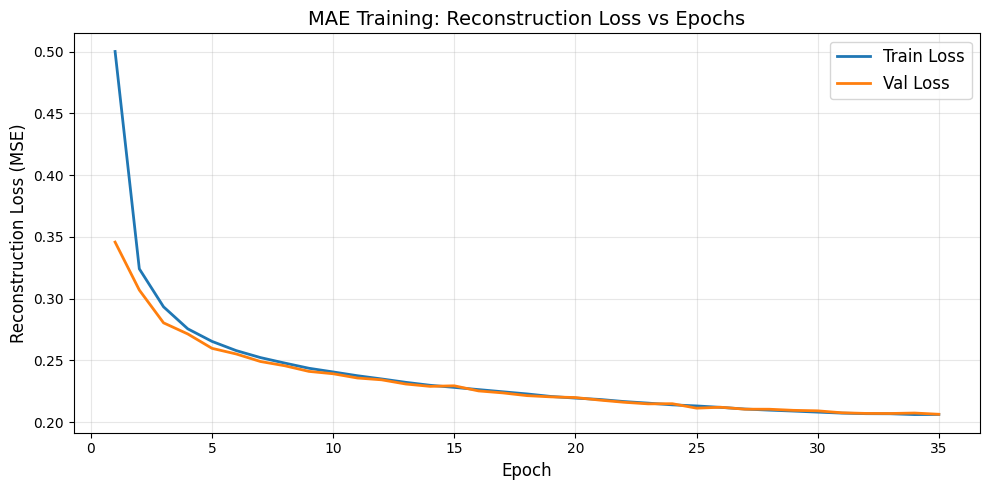

In [21]:
# Hyperparameters (matching assignment spec)
model = MaskedAutoencoder(
    img_size=224,
    patch_size=16,
    in_channels=3,
    encoder_embed_dim=768,
    encoder_depth=12,
    encoder_num_heads=12,
    decoder_embed_dim=384,
    decoder_depth=12,
    decoder_num_heads=6,
    mask_ratio=0.75
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
print(f"Total parameters: {total_params / 1e6:.1f}M")
print(f"Encoder parameters: {encoder_params / 1e6:.1f}M")
print(f"Decoder parameters: {decoder_params / 1e6:.1f}M")

# Train (adjust epochs based on time constraints)
# 50 epochs is ideal; 20-30 may be enough to show convergence
NUM_EPOCHS = 35
train_losses, val_losses = train_mae(
    model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS,
    lr=1.5e-4,
    weight_decay=0.05
)

# Save model
model_to_save = model.module if hasattr(model, 'module') else model
torch.save(model_to_save.state_dict(), 'mae_model.pth')
print("Model saved!")

plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', linewidth=2)
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('MAE Training: Reconstruction Loss vs Epochs', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

In [10]:
# Create fresh model (needed so we can load weights into it)
model = MaskedAutoencoder(
    img_size=224, patch_size=16, in_channels=3,
    encoder_embed_dim=768, encoder_depth=12, encoder_num_heads=12,
    decoder_embed_dim=384, decoder_depth=12, decoder_num_heads=6,
    mask_ratio=0.75
)

# Resume settings
RESUME_EPOCH = 35
TOTAL_EPOCHS = 55

# Load checkpoint
checkpoint = torch.load('mae_checkpoint_epoch_35.pth')
model.load_state_dict(checkpoint['model_state_dict'])

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=1.5e-4, weight_decay=0.05)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

scheduler = CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6)
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

scaler = GradScaler('cuda')
scaler.load_state_dict(checkpoint['scaler_state_dict'])

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']

print(f"✅ Loaded checkpoint from epoch {RESUME_EPOCH}")

✅ Loaded checkpoint from epoch 35


/tmp/ipykernel_55/4281092776.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler('cuda')


In [12]:
for epoch in range(RESUME_EPOCH, TOTAL_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            loss, pred, mask = model(images)
            loss = loss.mean()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()
        num_batches += 1
        if batch_idx % 100 == 0:
            print(f"  Epoch [{epoch+1}/{TOTAL_EPOCHS}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device, non_blocking=True)
            with autocast():
                loss, _, _ = model(images)
                loss = loss.mean()
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        model_to_save = model.module if hasattr(model, 'module') else model
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model_to_save.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }
        torch.save(checkpoint, f'mae_checkpoint_epoch_{epoch+1}.pth')
        print(f"  ✅ Checkpoint saved at epoch {epoch+1}")

    print(f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

model_to_save = model.module if hasattr(model, 'module') else model
torch.save(model_to_save.state_dict(), 'mae_model_final.pth')
print("🎉 Done!")

/tmp/ipykernel_55/3964056028.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


  Epoch [36/55] Batch [0/1562] Loss: 0.2114
  Epoch [36/55] Batch [100/1562] Loss: 0.2244
  Epoch [36/55] Batch [200/1562] Loss: 0.2156
  Epoch [36/55] Batch [300/1562] Loss: 0.2003
  Epoch [36/55] Batch [400/1562] Loss: 0.1935
  Epoch [36/55] Batch [500/1562] Loss: 0.2043
  Epoch [36/55] Batch [600/1562] Loss: 0.2031
  Epoch [36/55] Batch [700/1562] Loss: 0.2160
  Epoch [36/55] Batch [800/1562] Loss: 0.2153
  Epoch [36/55] Batch [900/1562] Loss: 0.2024
  Epoch [36/55] Batch [1000/1562] Loss: 0.2203
  Epoch [36/55] Batch [1100/1562] Loss: 0.2018
  Epoch [36/55] Batch [1200/1562] Loss: 0.2116
  Epoch [36/55] Batch [1300/1562] Loss: 0.2369
  Epoch [36/55] Batch [1400/1562] Loss: 0.1949
  Epoch [36/55] Batch [1500/1562] Loss: 0.2148


/tmp/ipykernel_55/3964056028.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [36/55] Train Loss: 0.2055 | Val Loss: 0.2053 | LR: 0.000001
  Epoch [37/55] Batch [0/1562] Loss: 0.1901
  Epoch [37/55] Batch [100/1562] Loss: 0.1814
  Epoch [37/55] Batch [200/1562] Loss: 0.2105
  Epoch [37/55] Batch [300/1562] Loss: 0.1712
  Epoch [37/55] Batch [400/1562] Loss: 0.2316
  Epoch [37/55] Batch [500/1562] Loss: 0.2287
  Epoch [37/55] Batch [600/1562] Loss: 0.2000
  Epoch [37/55] Batch [700/1562] Loss: 0.2013
  Epoch [37/55] Batch [800/1562] Loss: 0.1958
  Epoch [37/55] Batch [900/1562] Loss: 0.2117
  Epoch [37/55] Batch [1000/1562] Loss: 0.1944
  Epoch [37/55] Batch [1100/1562] Loss: 0.2189
  Epoch [37/55] Batch [1200/1562] Loss: 0.2273
  Epoch [37/55] Batch [1300/1562] Loss: 0.2032
  Epoch [37/55] Batch [1400/1562] Loss: 0.1875
  Epoch [37/55] Batch [1500/1562] Loss: 0.2181
Epoch [37/55] Train Loss: 0.2060 | Val Loss: 0.2063 | LR: 0.000002
  Epoch [38/55] Batch [0/1562] Loss: 0.2032
  Epoch [38/55] Batch [100/1562] Loss: 0.1809
  Epoch [38/55] Batch [200/1562] Los

KeyboardInterrupt: 

/tmp/ipykernel_55/1872832180.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


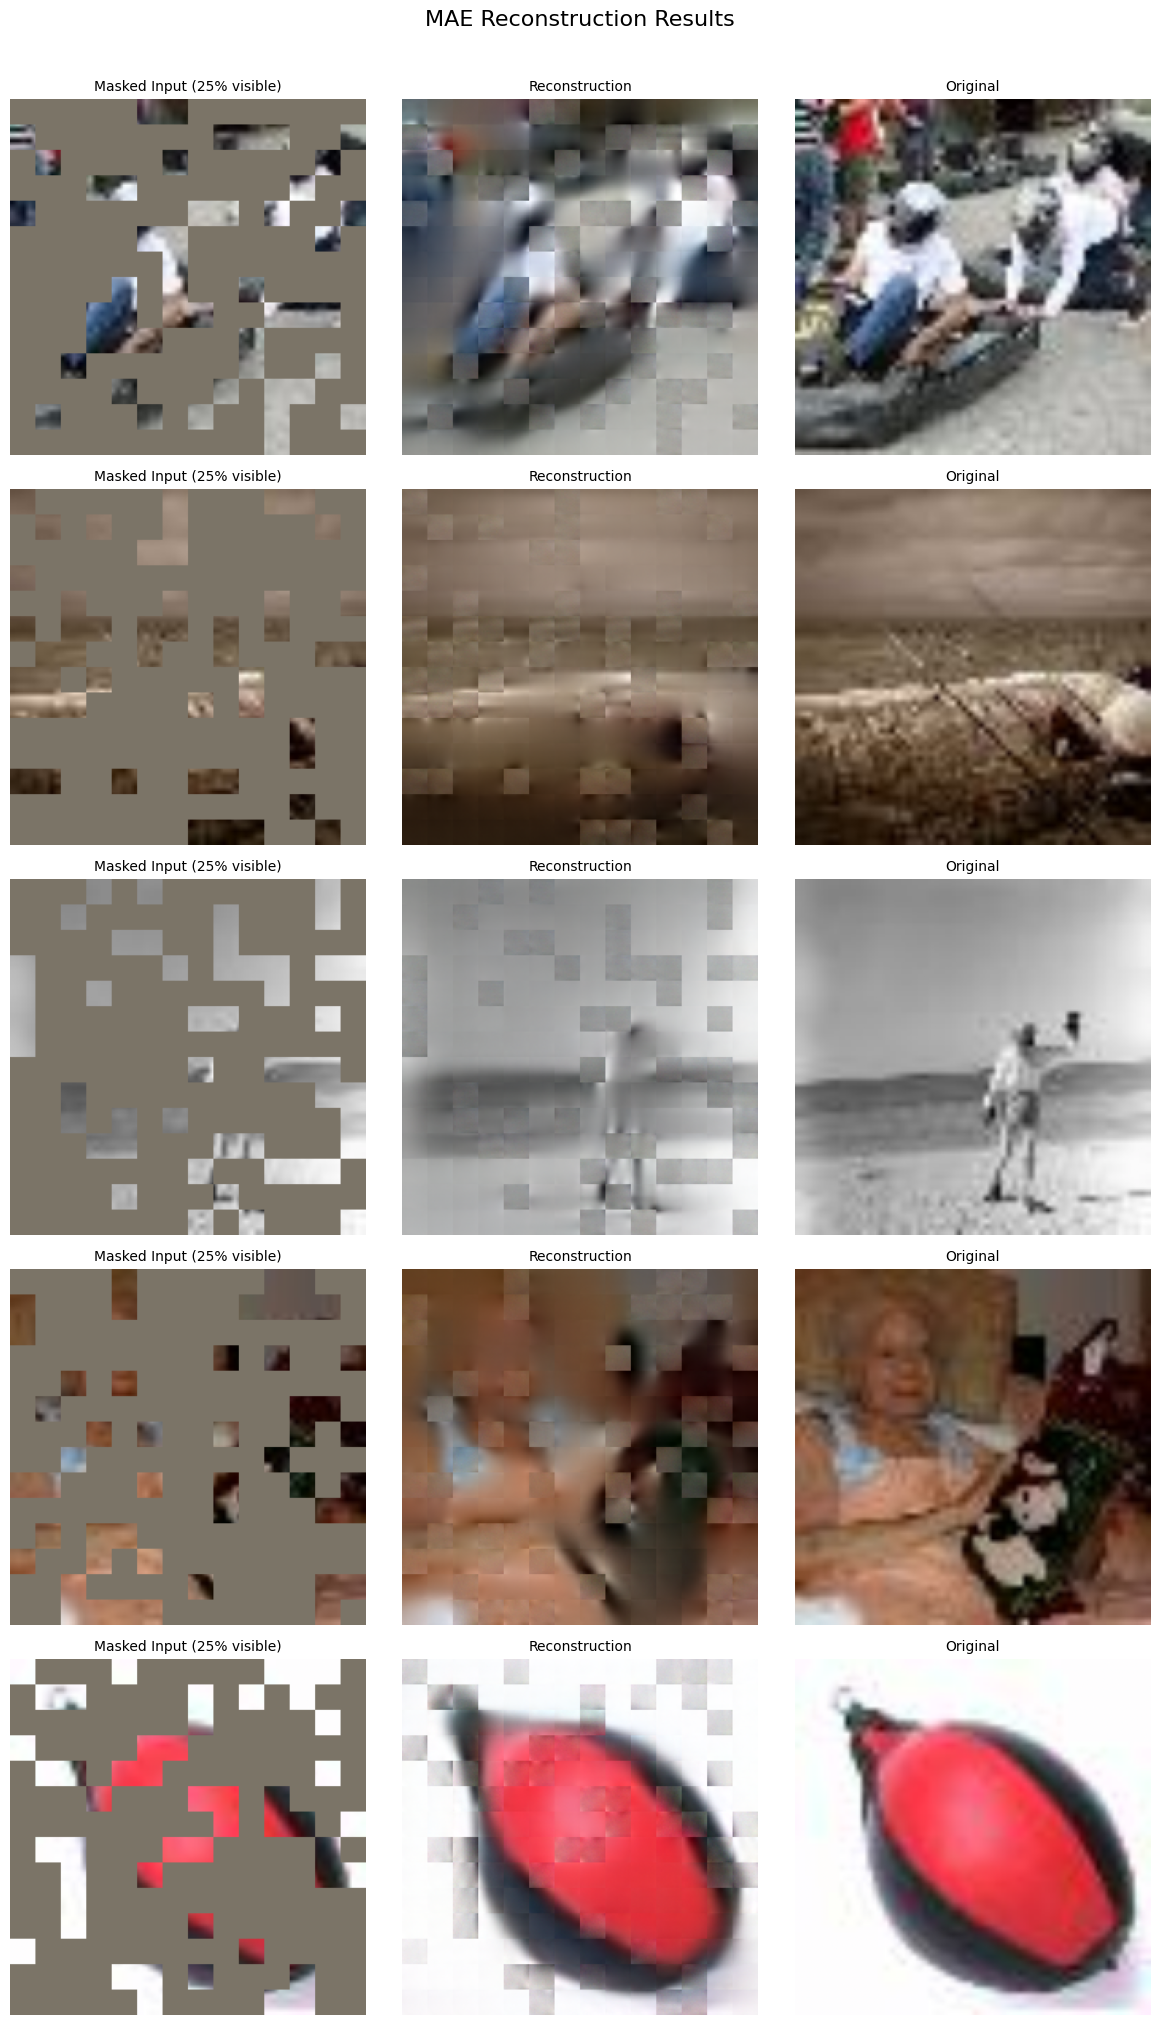

In [13]:

def denormalize(tensor):
    """Undo ImageNet normalization for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean


def visualize_reconstruction(model, dataloader, num_samples=5):
    """Show masked input, reconstruction, and original side by side."""
    model_to_use = model.module if hasattr(model, 'module') else model
    model_to_use.eval()
    
    # Get a batch
    images, _ = next(iter(dataloader))
    images = images[:num_samples].to(device)
    
    with torch.no_grad():
        with autocast():
            loss, pred, mask = model_to_use(images)
    
    # Convert predictions to images
    pred_imgs = model_to_use.unpatchify(pred)  # (B, 3, 224, 224)
    
    # Create masked input visualization
    # Patchify original, zero out masked patches, unpatchify
    patches = model_to_use.patchify(images)  # (B, 196, 768)
    masked_patches = patches.clone()
    masked_patches[~mask] = 0.0  # Zero out masked patches (they appear black)
    masked_imgs = model_to_use.unpatchify(masked_patches)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    for i in range(num_samples):
        # Denormalize for display
        orig = denormalize(images[i]).cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        masked = denormalize(masked_imgs[i]).cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        recon = denormalize(pred_imgs[i]).cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        
        axes[i, 0].imshow(masked)
        axes[i, 0].set_title('Masked Input (25% visible)', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(recon)
        axes[i, 1].set_title('Reconstruction', fontsize=10)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(orig)
        axes[i, 2].set_title('Original', fontsize=10)
        axes[i, 2].axis('off')
    
    plt.suptitle('MAE Reconstruction Results', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('reconstruction_results.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run visualization
visualize_reconstruction(model, val_loader, num_samples=5)


In [23]:
def compute_psnr(pred, target):
    """
    Compute Peak Signal-to-Noise Ratio.
    Both inputs should be in [0, 1] range.
    """
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float('inf')
    return 10 * torch.log10(1.0 / mse).item()


def compute_ssim(pred, target, window_size=11):
    """
    Compute Structural Similarity Index.
    Simplified implementation for evaluation.
    Both inputs: (B, C, H, W) in [0, 1] range.
    """
    C1 = 0.01 ** 2  # Stability constant for luminance
    C2 = 0.03 ** 2  # Stability constant for contrast
    
    # Create Gaussian window
    def gaussian_window(size, sigma=1.5):
        coords = torch.arange(size, dtype=torch.float32) - size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        return g.unsqueeze(0) * g.unsqueeze(1)  # 2D Gaussian
    
    window = gaussian_window(window_size).unsqueeze(0).unsqueeze(0)  # (1, 1, 11, 11)
    window = window.expand(pred.shape[1], -1, -1, -1).to(pred.device)  # (C, 1, 11, 11)
    
    pad = window_size // 2
    
    # Compute means
    mu1 = F.conv2d(pred, window, padding=pad, groups=pred.shape[1])
    mu2 = F.conv2d(target, window, padding=pad, groups=target.shape[1])
    
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu12 = mu1 * mu2
    
    # Compute variances and covariance
    sigma1_sq = F.conv2d(pred ** 2, window, padding=pad, groups=pred.shape[1]) - mu1_sq
    sigma2_sq = F.conv2d(target ** 2, window, padding=pad, groups=target.shape[1]) - mu2_sq
    sigma12 = F.conv2d(pred * target, window, padding=pad, groups=pred.shape[1]) - mu12
    
    # SSIM formula
    ssim_map = ((2 * mu12 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    
    return ssim_map.mean().item()


def evaluate_model(model, dataloader, num_batches=10):
    """Compute average PSNR and SSIM on validation set."""
    model_to_use = model.module if hasattr(model, 'module') else model
    model_to_use.eval()
    
    psnr_scores = []
    ssim_scores = []
    
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(dataloader):
            if batch_idx >= num_batches:
                break
            
            images = images.to(device)
            
            with autocast():
                loss, pred, mask = model_to_use(images)
            
            # Convert to image space and denormalize
            pred_imgs = model_to_use.unpatchify(pred.float())
            pred_imgs = denormalize(pred_imgs).clamp(0, 1)
            orig_imgs = denormalize(images).clamp(0, 1)
            
            # Compute metrics
            psnr = compute_psnr(pred_imgs, orig_imgs)
            ssim = compute_ssim(pred_imgs, orig_imgs)
            
            psnr_scores.append(psnr)
            ssim_scores.append(ssim)
    
    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)
    
    print(f"\n{'='*40}")
    print(f"Quantitative Evaluation Results")
    print(f"{'='*40}")
    print(f"Average PSNR: {avg_psnr:.2f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    print(f"{'='*40}")
    
    return avg_psnr, avg_ssim

# Run evaluation
avg_psnr, avg_ssim = evaluate_model(model, val_loader)


/tmp/ipykernel_55/4251110111.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Quantitative Evaluation Results
Average PSNR: 19.08 dB
Average SSIM: 0.5692
